In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import string
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import (
        confusion_matrix,
        accuracy_score,
        roc_auc_score,
        f1_score,
        RocCurveDisplay,
        classification_report
         )

## Loading Data

In [2]:
df=pd.read_csv('amazon.csv')

In [3]:
df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


## EDA

In [4]:
df.shape

(20000, 2)

In [5]:
df.columns

Index(['reviewText', 'Positive'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  20000 non-null  object
 1   Positive    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [7]:
df.describe()

,Positive
count,20000.000000
mean,0.761650
std,0.426085
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [8]:
df.isnull().sum()

reviewText    0
Positive      0
dtype: int64

In [9]:
df.Positive.value_counts()

Positive
1    15233
0     4767
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_4448\1959871123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x=df['Positive'],palette=['royalblue','tomato'])


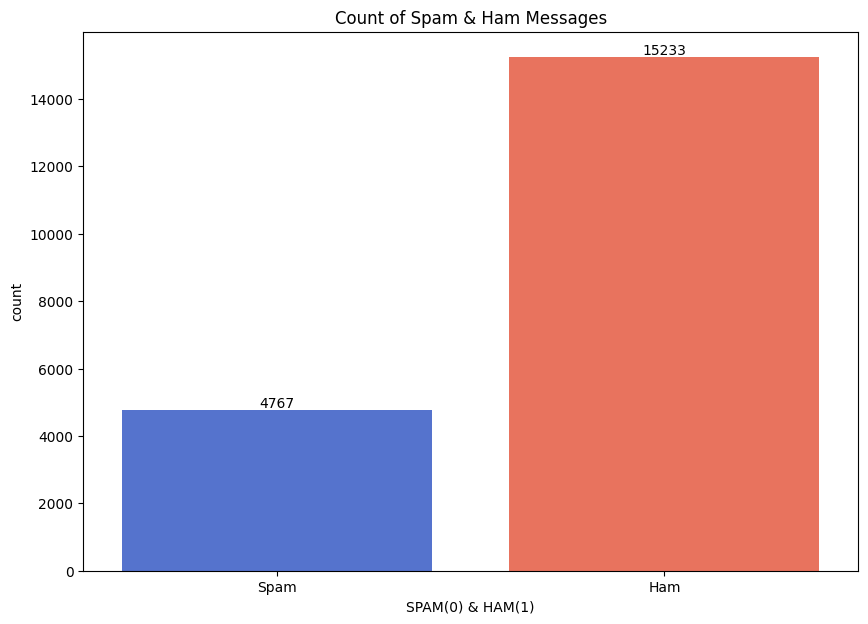

In [10]:
plt.figure(figsize=(10,7))
ax=sns.countplot(x=df['Positive'],palette=['royalblue','tomato'])

plt.title("Count of Spam & Ham Messages")
plt.xlabel('SPAM(0) & HAM(1)')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',   
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',color='black'
                )

plt.xticks([0,1],['Spam','Ham'])
plt.show()

In [11]:
postive_col = df['Positive'].value_counts()
index=postive_col.index
values=postive_col.values

# pie_df=pd.DataFrame(
#    {
#     "Spam or Ham":index,
#     "Count":values
#    }
# )

figure=px.pie(
    df['Positive'].value_counts(),
    values=values,
    names=index,
    hole=.60,
    title="Spam & Ham Status"
)
figure.show()

In [12]:
df

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1
...,...,...
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1


## Preprocessing

In [13]:
def plot_wordCloud(text,title):
    wordcloud=WordCloud(height=400,width=800,background_color="white").generate(text)
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


fake_text=' '.join(df[df['Positive']==0]['reviewText'])
real_text=' '.join(df[df['Positive']==1]['reviewText'])

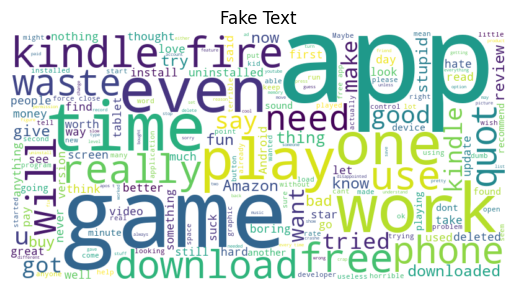

In [14]:
plot_wordCloud(fake_text,'Fake Text')

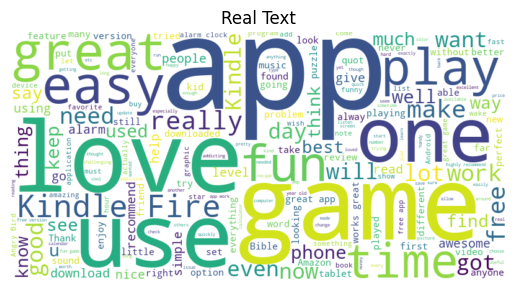

In [15]:
plot_wordCloud(real_text,'Real Text')

punctuation


In [16]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

stopwords

In [17]:
stopwords.fileids()

['albanian',
 'arabic',
 'azerbaijani',
 'basque',
 'belarusian',
 'bengali',
 'catalan',
 'chinese',
 'danish',
 'dutch',
 'english',
 'finnish',
 'french',
 'german',
 'greek',
 'hebrew',
 'hinglish',
 'hungarian',
 'indonesian',
 'italian',
 'kazakh',
 'nepali',
 'norwegian',
 'portuguese',
 'romanian',
 'russian',
 'slovene',
 'spanish',
 'swedish',
 'tajik',
 'tamil',
 'turkish']

In [18]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
def remove_punc_stopwords(text):
    removed_punc=''.join([word for word in text if word not in string.punctuation])
    
    words=removed_punc.split()
    removed_stopwords=' '.join([word for word in words if word.lower() not in set(stopwords.words('english'))])

    return removed_stopwords
   
        

In [20]:
df['reviewText']=df['reviewText'].apply(remove_punc_stopwords)

In [21]:
df['reviewText']

0        one best apps acording bunch people agree bomb...
1        pretty good version game free LOTS different l...
2        really cool game bunch levels find golden eggs...
3        silly game frustrating lots fun definitely rec...
4        terrific game pad Hrs fun grandkids love Great...
                               ...                        
19995    app fricken stupidit froze kindle wont allow p...
19996    Please add need neighbors Ginger1016 thanks bu...
19997    love game awesome wish free stuff houses didnt...
19998    love love love app side fashion story fights w...
19999    game rip list things MAKE BETTERbull First NEE...
Name: reviewText, Length: 20000, dtype: object

Lemmatization

In [22]:
lm=WordNetLemmatizer()

def text_lemtize(text):
    lematized_text=' '.join([lm.lemmatize(word) for word in text.split()])
    return lematized_text

In [23]:
df['reviewText']=df['reviewText'].apply(text_lemtize)

In [24]:
df['reviewText']

0        one best apps acording bunch people agree bomb...
1        pretty good version game free LOTS different l...
2        really cool game bunch level find golden egg s...
3        silly game frustrating lot fun definitely reco...
4        terrific game pad Hrs fun grandkids love Great...
                               ...                        
19995    app fricken stupidit froze kindle wont allow p...
19996    Please add need neighbor Ginger1016 thanks bun...
19997    love game awesome wish free stuff house didnt ...
19998    love love love app side fashion story fight wo...
19999    game rip list thing MAKE BETTERbull First NEED...
Name: reviewText, Length: 20000, dtype: object

Train_Test_Split

In [25]:
X_raw = df['reviewText']
y=df['Positive'] 

In [26]:
xtrain_raw, xtest_raw, ytrain, ytest = train_test_split(X_raw,y,test_size=0.3,random_state=42) 

In [27]:
xtrain_raw.shape

(14000,)

In [28]:
xtrain_raw.head()

17218    QC app great Android shopped w QVC 15 year ser...
15188    another big failure nice calendar sync Google ...
11295    ever EFarrow person dont listen himthis app co...
19772    didnt even 2 gt stupid app read review see ifi...
13072    Tons option smooth animation work better Googl...
Name: reviewText, dtype: object

In [29]:
ytrain.shape

(14000,)

In [30]:
ytrain.head()

17218    1
15188    0
11295    1
19772    0
13072    1
Name: Positive, dtype: int64

In [31]:
xtest_raw.head()

10650    app great especially get stuck vowel one lette...
2041     Doesnt work great Kindle fire bummer young kid...
8668     bit hard find search find search button hide well
1114     ap easy use use often making reservation espec...
13902    enjoy thrill slot coin game time graphic excit...
Name: reviewText, dtype: object

In [32]:
ytest.head()

10650    1
2041     0
8668     1
1114     1
13902    1
Name: Positive, dtype: int64

In [33]:
ytest.shape

(6000,)

## Vectorizer

In [34]:
TF_ID_vec = TfidfVectorizer()

In [35]:
Xtrain=TF_ID_vec.fit_transform(xtrain_raw)
Xtest=TF_ID_vec.transform(xtest_raw)

In [36]:
Xtrain.shape

(14000, 18167)

In [37]:
Xtest.shape

(6000, 18167)

## Evaluation Metrics

In [38]:
def evaluate_model(bnb_model,x_test,ytest):
    y_pred = bnb_model.predict(x_test)
    accuracy=accuracy_score(ytest,y_pred)
    confusion_Matrix=confusion_matrix(ytest,y_pred)
    return { 
        "Accuracy":accuracy, 
        "confusion_Matrix":confusion_Matrix }
    

In [39]:
def plot_confusion_matrix(cm,Title):
    plt.figure(figsize=(10,7))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0','Predicted 1'],
        yticklabels=['Actual 0','Actual 1']
    )
    plt.xlabel("Predicted") 
    plt.ylabel("Actual") 
    plt.title(Title)
    plt.show()
    return

## Bernouli Naive Bayes

{'Accuracy': 0.8715, 'confusion_Matrix': array([[ 779,  632],
       [ 139, 4450]])}


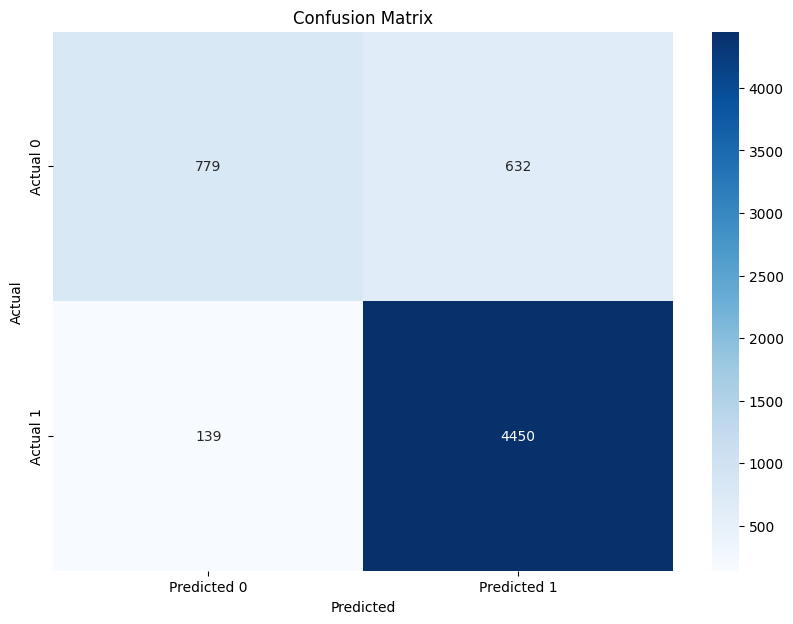

None


In [40]:
bnb_model=BernoulliNB()
bnb_model.fit(Xtrain,ytrain)

bnb_results = evaluate_model(bnb_model,Xtest,ytest)
print(bnb_results)

confusion_Matrix = plot_confusion_matrix(bnb_results['confusion_Matrix'],'Confusion Matrix')
print(confusion_Matrix)

Classification Report

In [41]:
cr=classification_report(ytest,bnb_model.predict(Xtest),digits=3)
print(cr)

              precision    recall  f1-score   support

           0      0.849     0.552     0.669      1411
           1      0.876     0.970     0.920      4589

    accuracy                          0.872      6000
   macro avg      0.862     0.761     0.795      6000
weighted avg      0.869     0.872     0.861      6000



## AUC and ROC curve

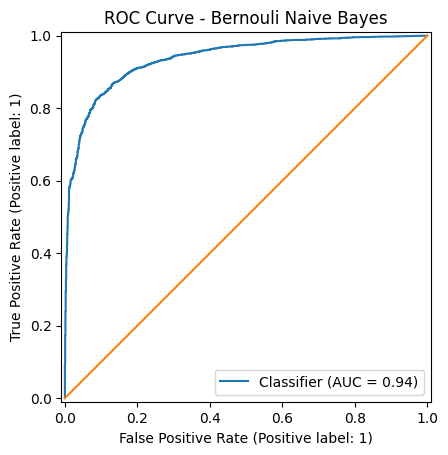

In [42]:
bnb_proba = bnb_model.predict_proba(Xtest)[:,1]
RocCurveDisplay.from_predictions(ytest,bnb_proba)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Bernouli Naive Bayes")
plt.show()

In [43]:
pd.DataFrame(bnb_proba)

,0
0,0.999845
1,0.974911
2,0.990615
3,1.000000
4,0.999998
...,...
5995,0.368929
5996,0.999372
5997,0.989124
5998,0.999423


## Multinomial Naive Bayes

{'Accuracy': 0.7923333333333333, 'confusion_Matrix': array([[ 173, 1238],
       [   8, 4581]])}


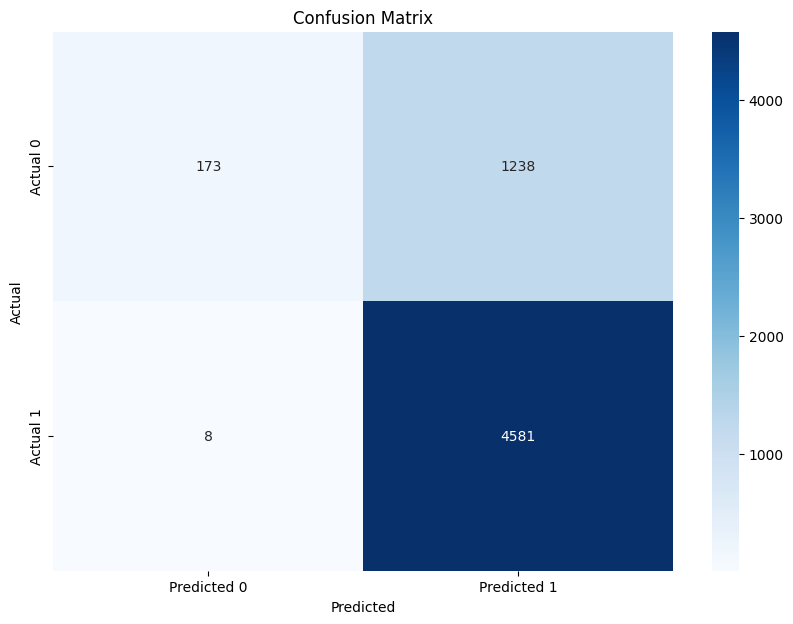

In [44]:
mnb_model=MultinomialNB()
mnb_model.fit(Xtrain,ytrain)

mnb_accuracy = evaluate_model(mnb_model,Xtest,ytest)
print(mnb_accuracy)

plot_confusion_matrix(mnb_accuracy['confusion_Matrix'],'Confusion Matrix')

Classification Report

In [45]:
print(classification_report(ytest,mnb_model.predict(Xtest),digits=3))

              precision    recall  f1-score   support

           0      0.956     0.123     0.217      1411
           1      0.787     0.998     0.880      4589

    accuracy                          0.792      6000
   macro avg      0.872     0.560     0.549      6000
weighted avg      0.827     0.792     0.724      6000



ROC Curve Display

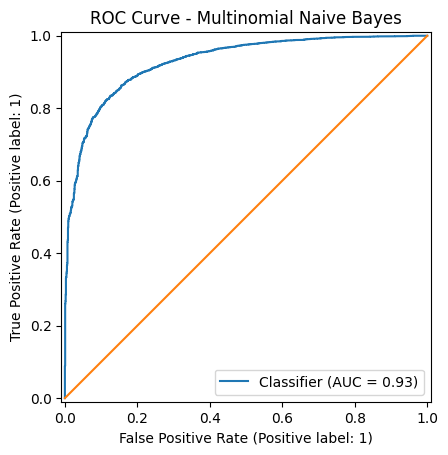

In [46]:
mnb_proba = mnb_model.predict_proba(Xtest)[:,1]
RocCurveDisplay.from_predictions(ytest,mnb_proba)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Multinomial Naive Bayes")
plt.show()

## Logistic Regression

{'Accuracy': 0.8871666666666667, 'confusion_Matrix': array([[ 885,  526],
       [ 151, 4438]])}


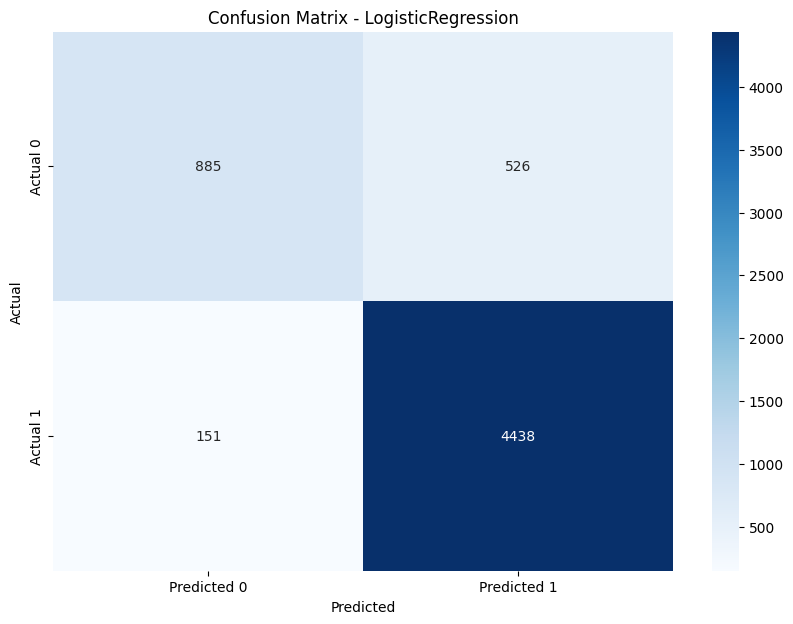

None


In [47]:
lr_model=LogisticRegression(max_iter=10000,penalty='l2')
lr_model.fit(Xtrain,ytrain)

lr_accuracy = evaluate_model(lr_model,Xtest,ytest)
print(lr_accuracy)

lr_cm=plot_confusion_matrix(lr_accuracy['confusion_Matrix'],'Confusion Matrix - LogisticRegression')
print(lr_cm)

Classification Report

In [48]:
print(classification_report(ytest,lr_model.predict(Xtest),digits=3))

              precision    recall  f1-score   support

           0      0.854     0.627     0.723      1411
           1      0.894     0.967     0.929      4589

    accuracy                          0.887      6000
   macro avg      0.874     0.797     0.826      6000
weighted avg      0.885     0.887     0.881      6000



ROC Curve

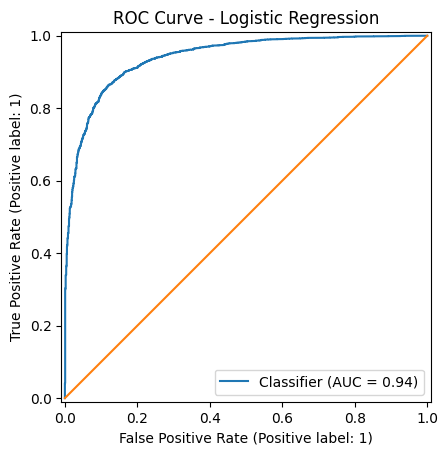

In [49]:
lr_proba=lr_model.predict_proba(Xtest)[:,1]
RocCurveDisplay.from_predictions(ytest,lr_proba)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Logistic Regression")
plt.show()

## Evaluation All Together

In [50]:
def plot_all_models(accuracy,model_names,metric_name):
    fig,ax = plt.subplots(figsize=(10,7))
    bars = ax.bar(model_names,accuracy)
    plt.title(f"{metric_name} for different models")
    plt.xlabel("Model Names")
    plt.ylabel("Model Accuracy")

    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),
                round(bar.get_height(),3),
                ha='center', va='bottom',color='black'
                )


    plt.show()

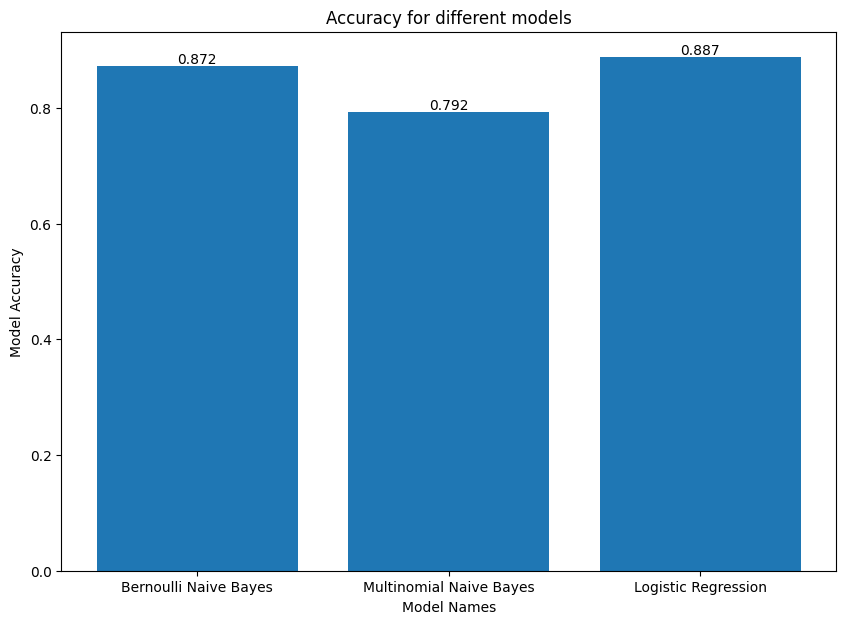

In [51]:
accuracy=[bnb_results['Accuracy'],mnb_accuracy['Accuracy'],lr_accuracy['Accuracy']]
model_names=['Bernoulli Naive Bayes', 'Multinomial Naive Bayes', 'Logistic Regression']

plot_all_models(accuracy,model_names,'Accuracy')

Save File

In [52]:
import pickle

file_path='logistic_Regression.pkl'

with open(file_path,'wb') as model_file:
    pickle.dump(
        {
            "model":lr_model,
            "vectorizer":TF_ID_vec
        },
        model_file
    )
    
print(f"Saved Logistic Regression model and vectorizer to: {file_path}")

Saved Logistic Regression model and vectorizer to: logistic_Regression.pkl


Load

In [53]:
with open(file_path,'rb') as model_file:
    saved_objects=pickle.load(model_file)

loaded_LR = saved_objects['model']
loaded_Vectorizer = saved_objects['vectorizer']

print(type(loaded_LR))
print(type(loaded_Vectorizer))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [54]:
saved_objects['model']

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


## Predict random text

In [100]:


def predict_text(text):

    ## predicted value
    remove_punc_stopword=remove_punc_stopwords(text)
    lematized_text = text_lemtize(remove_punc_stopword)
    vectorized = loaded_Vectorizer.transform([lematized_text])

    prediction = loaded_LR.predict(vectorized)[0]

    print(f'Predicted result is : {prediction}')
 
    ## probability
    predicted_proba = None

    if hasattr(loaded_LR,"predict_proba"):
        predicted_proba = loaded_LR.predict_proba(vectorized)[0,1]
        print(predicted_proba)

    if predicted_proba is not None:
        print(f"Predicted probability for class-1 is: {round(predicted_proba,4)}")
    

    return prediction, predicted_proba


In [89]:
text='this is a really cool game. there are a bunch of levels and you can find golden eggs. super fun.'

In [101]:
predict_text(text)

Predicted result is : 1
0.9584515113391484
Predicted probability for class-1 is: 0.9585


(np.int64(1), np.float64(0.9584515113391484))